# Entrenamiento LSTM — Detección de Caídas LE2I
**Pipeline:** YOLOv11 → MediaPipe → LSTM  
**Dataset:** LE2I DIJON UMR6306  
**Clases:** `-1` normal · `0` caída · `1` post-caída

In [337]:
# %% [markdown]
# ## 0. Construcción de secuencias
# Corre esta celda para regenerar los datos sin necesidad de ejecutar `build_sequences.py` por separado.
# Cambia `FEATURE_MODE` para experimentar con distintas combinaciones de features.

# %%
import numpy as np
import pandas as pd
from pathlib import Path

# ── Configuración de datos ─────────────────────────────────────────────────────
KEYPOINTS_DIRS = [
    "Coffee_room/keypoints_yolo/",   # agrega o quita carpetas aquí
    "Home_room/keypoints_yolo/",
    "Fall_vision/f_raw_s_1/keypoints",
    # "Urfall/keypoints"
    # "Office/keypoints_tunned",
    # "Lecture_room/keypoints_tunned",
]
DATA_DIR   = Path("./lstm_data")
WINDOW     = 20    # frames por ventana
STRIDE     = 10    # stride entre ventanas
MIN_VALID  = 0.7   # fracción mínima de frames con keypoints válidos
MAX_FALL_RATIO = None

# ── Selector de features ───────────────────────────────────────────────────────
# Todos los 33 puntos MediaPipe:
#   "full"        → x,y,z,vis         (132 features)
#   "xy"          → x,y               ( 66 features)
#   "xyz"         → x,y,z             ( 99 features)
#   "xy_vel"      → x,y + vel x,y     (132 features)
#   "full_vel"    → x,y,z,vis + vel   (198 features)
# Solo 17 puntos COCO (equivalente a YOLO-pose):
#   "coco"        → x,y,z,vis         ( 68 features)
#   "coco_xy"     → x,y               ( 34 features)
#   "coco_vel"    → x,y,z,vis + vel   (136 features)
#   "coco_xy_vel"        → x,y + vel x,y              ( 68 features)
#   "coco_xy_vel_angles" → x,y + vel x,y + 8 ángulos  ( 73 features)
FEATURE_MODE = "coco_xy_vel"

# ──────────────────────────────────────────────────────────────────────────────

N_LANDMARKS = 33
ALL_DIMS    = ("x", "y", "z", "vis")
ALL_KP_COLS = [f"kp_{i}_{dim}" for i in range(N_LANDMARKS) for dim in ALL_DIMS]

# Índices de los 17 puntos COCO en MediaPipe
# (equivalentes a los keypoints de YOLO-pose)
COCO_INDICES = [0, 1, 2, 7, 8, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]

def get_feature_cols(mode):
    if mode == "xy":
        return [f"kp_{i}_{d}" for i in range(N_LANDMARKS) for d in ("x", "y")]
    elif mode == "xyz":
        return [f"kp_{i}_{d}" for i in range(N_LANDMARKS) for d in ("x", "y", "z")]
    elif mode == "coco":
        return [f"kp_{i}_{d}" for i in COCO_INDICES for d in ("x", "y", "z", "vis")]
    elif mode == "coco_xy":
        return [f"kp_{i}_{d}" for i in COCO_INDICES for d in ("x", "y")]
    elif mode == "coco_vel":
        return [f"kp_{i}_{d}" for i in COCO_INDICES for d in ("x", "y", "z", "vis")]
    elif mode in ("coco_xy_vel", "coco_xy_vel_angles"):
        return [f"kp_{i}_{d}" for i in COCO_INDICES for d in ("x", "y")]
    else:  # "full", "xy_vel", "full_vel"
        return ALL_KP_COLS

def add_velocity(window_kps, mode):
    """Agrega velocidad (diferencia entre frames consecutivos) a los features."""
    if "vel" not in mode:
        return window_kps
    # Calcular velocidad para las columnas x,y
    feat_cols = get_feature_cols(mode)
    xy_col_idx = [i for i, c in enumerate(feat_cols) if c.endswith("_x") or c.endswith("_y")]
    xy = window_kps[:, xy_col_idx]
    vel = np.zeros_like(xy)
    vel[1:] = xy[1:] - xy[:-1]
    return np.concatenate([window_kps, vel], axis=1)

# Ángulos relevantes para detección de caídas
# Cada ángulo definido por 3 puntos (A, B, C) donde B es el vértice
# Índices MediaPipe
ANGLE_TRIPLETS = [
    # Ángulos robustos al ángulo de cámara — relaciones verticales del cuerpo
    ("trunk_lean",     11,  12,  24),  # hombro_izq - hombro_der - cadera_der
    ("spine_angle",     0,  12,  24),  # nariz - hombro_der - cadera_der
    ("head_hip_left",   0,  11,  23),  # nariz - hombro_izq - cadera_izq
    ("head_hip_right",  0,  12,  24),  # nariz - hombro_der - cadera_der
    ("hip_symmetry",   23,  24,  26),  # cadera_izq - cadera_der - rodilla_der
]

def add_angles(window_kps, df_window):
    """Versión vectorizada — calcula todos los ángulos de una vez."""
    angles = np.zeros((len(window_kps), len(ANGLE_TRIPLETS)), dtype=np.float32)
    
    for j, (name, a, b, c) in enumerate(ANGLE_TRIPLETS):
        ax = df_window[f"kp_{a}_x"].values
        ay = df_window[f"kp_{a}_y"].values
        bx = df_window[f"kp_{b}_x"].values
        by = df_window[f"kp_{b}_y"].values
        cx = df_window[f"kp_{c}_x"].values
        cy = df_window[f"kp_{c}_y"].values

        v1x, v1y = ax - bx, ay - by
        v2x, v2y = cx - bx, cy - by

        norm1 = np.sqrt(v1x**2 + v1y**2)
        norm2 = np.sqrt(v2x**2 + v2y**2)

        valid = (norm1 > 0) & (norm2 > 0)
        dot   = v1x * v2x + v1y * v2y

        cos_angle = np.where(valid, np.clip(dot / (norm1 * norm2 + 1e-8), -1.0, 1.0), 0.0)
        angles[:, j] = np.where(valid, np.degrees(np.arccos(cos_angle)), 0.0)

    angles = angles / 180.0
    return np.concatenate([window_kps, angles], axis=1)
def interpolate_nans(window):
    result = window.copy()
    for col in range(result.shape[1]):
        col_data = result[:, col]
        nan_mask = np.isnan(col_data)
        if not nan_mask.any():
            continue
        if nan_mask.all():
            result[:, col] = 0.0
            continue
        indices   = np.arange(len(col_data))
        valid_idx = indices[~nan_mask]
        valid_val = col_data[~nan_mask]
        result[:, col] = np.interp(indices, valid_idx, valid_val)
    return result

def majority_label(labels):
    values, counts = np.unique(labels, return_counts=True)
    return int(values[counts.argmax()])

def valid_frame_ratio(window_kps):
    return (~np.isnan(window_kps[:, 0])).mean()

def build_sequences_from_df(df, window, stride, min_valid, video_name, feat_cols, mode):
    kp_values    = df[feat_cols].values.astype(np.float32)
    label_values = df["label"].values.astype(np.int8)
    frame_nums   = df["frame"].values

    sequences, labels, meta = [], [], []
    T = len(df)

    for start in range(0, T - window + 1, stride):
        end = start + window
        window_kps    = kp_values[start:end]
        window_labels = label_values[start:end]
        window_frames = frame_nums[start:end]

        if valid_frame_ratio(window_kps) < min_valid:
            continue

        window_kps = interpolate_nans(window_kps)
        window_kps = add_velocity(window_kps, mode)

        if "angles" in mode:
            df_window = df.iloc[start:end].reset_index(drop=True)
            window_kps = add_angles(window_kps, df_window)

        label = majority_label(window_labels)
        sequences.append(window_kps)
        labels.append(label)
        meta.append({
            "video":        video_name,
            "frame_inicio": int(window_frames[0]),
            "frame_fin":    int(window_frames[-1]),
            "label":        label,
        })
    return sequences, labels, meta


# ── Procesar todos los CSVs ────────────────────────────────────────────────────
feat_cols = get_feature_cols(FEATURE_MODE)
DATA_DIR.mkdir(parents=True, exist_ok=True)

csv_files = []
for kdir in KEYPOINTS_DIRS:
    csv_files.extend(sorted(Path(kdir).glob("*.csv")))

if not csv_files:
    raise FileNotFoundError(f"No se encontraron CSVs en: {KEYPOINTS_DIRS}")

all_sequences, all_labels, all_meta = [], [], []

for csv_path in csv_files:
    df = pd.read_csv(csv_path).sort_values("frame").reset_index(drop=True)
    video_name = f"{csv_path.parent.parent.name}/{csv_path.stem}"
    seqs, labs, meta = build_sequences_from_df(
        df, WINDOW, STRIDE, MIN_VALID, video_name, feat_cols, FEATURE_MODE
    )
    n0, n1, n2 = labs.count(-1), labs.count(0), labs.count(1)
    print(f"  {csv_path.name:30s} → {len(seqs):4d} ventanas  (-1:{n0:3d} 0:{n1:3d} 1:{n2:3d})")
    all_sequences.extend(seqs)
    all_labels.extend(labs)
    all_meta.extend(meta)

if MAX_FALL_RATIO is not None:
    import random
    random.seed(42)

    idx_normal  = [i for i, l in enumerate(all_labels) if l == -1]
    idx_fall    = [i for i, l in enumerate(all_labels) if l ==  0]
    idx_post    = [i for i, l in enumerate(all_labels) if l ==  1]

    n_non_fall  = len(idx_normal) + len(idx_post)
    max_fall    = int(n_non_fall * MAX_FALL_RATIO / (1 - MAX_FALL_RATIO))
    
    if len(idx_fall) > max_fall:
        idx_fall = random.sample(idx_fall, max_fall)
        print(f"\n⚖️  Balanceo: clase 0 reducida de {(all_labels.count(0))} → {max_fall} ventanas")

    keep = sorted(idx_normal + idx_fall + idx_post)
    all_sequences = [all_sequences[i] for i in keep]
    all_labels    = [all_labels[i]    for i in keep]
    all_meta      = [all_meta[i]      for i in keep]

X     = np.array(all_sequences, dtype=np.float32)
y_raw = np.array(all_labels,    dtype=np.int8)
meta_df = pd.DataFrame(all_meta)

np.save(DATA_DIR / "sequences.npy", X)
np.save(DATA_DIR / "labels.npy",    y_raw)
meta_df.to_csv(DATA_DIR / "meta.csv", index=False)

N_FEATURES = X.shape[2]  # se actualiza automáticamente según FEATURE_MODE

print(f"\n{'─'*55}")
print(f"✔  FEATURE_MODE : {FEATURE_MODE}  →  {N_FEATURES} features/frame")
print(f"   Shape X      : {X.shape}  (ventanas, frames, features)")
print(f"   Clase -1     : {(y_raw==-1).sum():5d} ({(y_raw==-1).mean()*100:.1f}%)")
print(f"   Clase  0     : {(y_raw== 0).sum():5d} ({(y_raw== 0).mean()*100:.1f}%)")
print(f"   Clase  1     : {(y_raw== 1).sum():5d} ({(y_raw== 1).mean()*100:.1f}%)")

  video (1).csv                  →   13 ventanas  (-1:  3 0:  4 1:  6)
  video (10).csv                 →   35 ventanas  (-1: 21 0:  2 1: 12)
  video (11).csv                 →   47 ventanas  (-1: 37 0:  3 1:  7)
  video (12).csv                 →   17 ventanas  (-1:  5 0:  2 1: 10)
  video (13).csv                 →   10 ventanas  (-1:  9 0:  1 1:  0)
  video (14).csv                 →   16 ventanas  (-1:  5 0:  2 1:  9)
  video (15).csv                 →   13 ventanas  (-1:  4 0:  3 1:  6)
  video (16).csv                 →   16 ventanas  (-1:  4 0:  2 1: 10)
  video (17).csv                 →   14 ventanas  (-1:  1 0:  4 1:  9)
  video (18).csv                 →   25 ventanas  (-1: 15 0:  3 1:  7)
  video (19).csv                 →   20 ventanas  (-1:  8 0:  4 1:  8)
  video (2).csv                  →   29 ventanas  (-1: 19 0:  2 1:  8)
  video (20).csv                 →   43 ventanas  (-1: 32 0:  5 1:  6)
  video (21).csv                 →   17 ventanas  (-1:  8 0:  2 1:  7)
  vide

## 1. Imports y configuración

In [338]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

# ── Configuración ──────────────────────────────────────────────
DATA_DIR    = Path("./lstm_data")   # carpeta con sequences.npy y labels.npy                
N_FEATURES  = X.shape[2]                  # 33 landmarks × (x,y,z,vis)
N_CLASSES   = 3                     # -1, 0, 1
LABEL_MAP   = {-1: 0, 0: 1, 1: 2}  # remapeo para CrossEntropy (necesita 0,1,2)
LABEL_NAMES = ["Normal (-1)", "Caída (0)", "Post-caída (1)"]

# Hiperparámetros
HIDDEN_SIZE  = 128
NUM_LAYERS   = 2
DROPOUT      = 0.3
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-3
VAL_SIZE     = 0.2
TEST_SIZE    = 0.1
SEED         = 42
PATIENCE_ES  = 10    # épocas sin mejora antes de parar

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

torch.manual_seed(SEED)
np.random.seed(SEED)

Dispositivo: cuda


## 2. Carga y exploración de datos

In [339]:
X = np.load(DATA_DIR / "sequences.npy")   # (N, 20, 132)
y_raw = np.load(DATA_DIR / "labels.npy")  # (N,) con valores -1, 0, 1
meta = pd.read_csv(DATA_DIR / "meta.csv")

# Remapear etiquetas a 0,1,2 para PyTorch
y = np.array([LABEL_MAP[l] for l in y_raw], dtype=np.int64)

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"\nDistribución de clases:")
for label, name in zip([0,1,2], LABEL_NAMES):
    n = (y == label).sum()
    print(f"  {name:20s}: {n:5d} ({n/len(y)*100:.1f}%)")

Shape X : (6142, 20, 68)
Shape y : (6142,)

Distribución de clases:
  Normal (-1)         :  3046 (49.6%)
  Caída (0)           :  2471 (40.2%)
  Post-caída (1)      :   625 (10.2%)


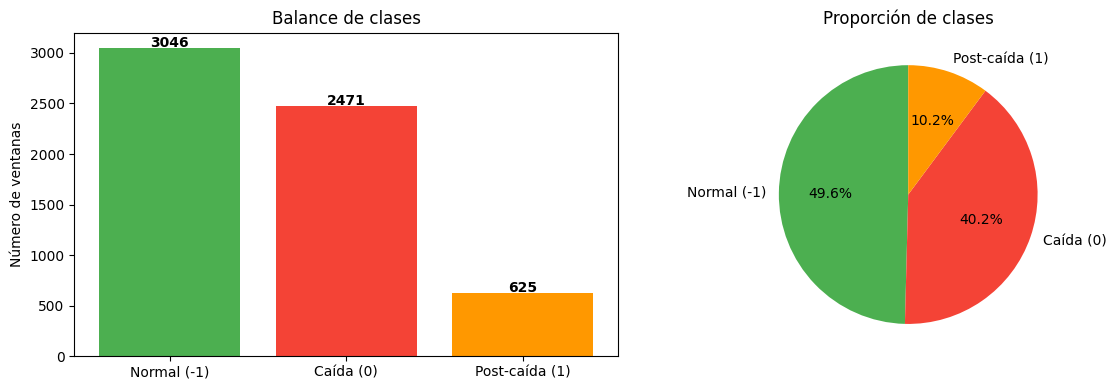

In [340]:
# Visualización del balance de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = [int((y == i).sum()) for i in range(3)]
colors = ["#4CAF50", "#F44336", "#FF9800"]

axes[0].bar(LABEL_NAMES, counts, color=colors)
axes[0].set_title("Balance de clases")
axes[0].set_ylabel("Número de ventanas")
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

axes[1].pie(counts, labels=LABEL_NAMES, colors=colors, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Proporción de clases")

plt.tight_layout()
plt.show()

In [341]:
# Distribución de ventanas por video
meta["label_name"] = meta["label"].map({-1: "Normal", 0: "Caída", 1: "Post-caída"})
video_summary = meta.groupby("video")["label"].value_counts().unstack(fill_value=0)
print("Ventanas por video:")
print(video_summary.to_string())

Ventanas por video:
label                                     -1   0   1
video                                               
Coffee_room/video (1)                      3   4   6
Coffee_room/video (10)                    21   2  12
Coffee_room/video (11)                    37   3   7
Coffee_room/video (12)                     5   2  10
Coffee_room/video (13)                     9   1   0
Coffee_room/video (14)                     5   2   9
Coffee_room/video (15)                     4   3   6
Coffee_room/video (16)                     4   2  10
Coffee_room/video (17)                     1   4   9
Coffee_room/video (18)                    15   3   7
Coffee_room/video (19)                     8   4   8
Coffee_room/video (2)                     19   2   8
Coffee_room/video (20)                    32   5   6
Coffee_room/video (21)                     8   2   7
Coffee_room/video (22)                    12   2   7
Coffee_room/video (23)                    20   4   4
Coffee_room/video (24)    

## 3. Split train / val / test
> El split se hace **por video** (usando meta.csv) para evitar data leakage — ventanas del mismo video no pueden estar en train y test a la vez.

In [342]:
videos = meta["video"].unique()

# Split por video
train_vids, test_vids = train_test_split(videos, test_size=TEST_SIZE, random_state=SEED)
train_vids, val_vids  = train_test_split(train_vids, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=SEED)

train_idx = meta[meta["video"].isin(train_vids)].index.values
val_idx   = meta[meta["video"].isin(val_vids)].index.values
test_idx  = meta[meta["video"].isin(test_vids)].index.values

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print(f"Train : {len(X_train):4d} ventanas ({len(train_vids)} videos)")
print(f"Val   : {len(X_val):4d} ventanas ({len(val_vids)} videos)")
print(f"Test  : {len(X_test):4d} ventanas ({len(test_vids)} videos)")

Train : 4185 ventanas (259 videos)
Val   : 1189 ventanas (75 videos)
Test  :  768 ventanas (38 videos)


## 4. Dataset y DataLoader

In [343]:
class FallDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Class weights para manejar el desbalance
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * N_CLASSES  # normalizar
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(y_train),
    replacement=True
)

train_ds = FallDataset(X_train, y_train)
val_ds   = FallDataset(X_val,   y_val)
test_ds  = FallDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Class weights: Normal={class_weights[0]:.3f} | Caída={class_weights[1]:.3f} | Post-caída={class_weights[2]:.3f}")

Class weights: Normal=0.445 | Caída=0.514 | Post-caída=2.041


## 5. Modelo LSTM

In [344]:
class FallLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout= dropout if num_layers > 1 else 0,
            bidirectional=False,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)       # (batch, seq_len, hidden)
        out = out[:, -1, :]         # último timestep
        out = self.dropout(out)
        return self.fc(out)         # (batch, num_classes)


model = FallLSTM(
    input_size=N_FEATURES,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=N_CLASSES,
    dropout=DROPOUT,
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")

FallLSTM(
  (lstm): LSTM(68, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

Parámetros entrenables: 233,859


## 6. Entrenamiento

In [345]:
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb)
            loss = criterion(preds, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct    += (preds.argmax(1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss   = float("inf")
best_model_path = DATA_DIR / "best_model.pt"
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        saved = "✅"
    else:
        patience_counter += 1
        saved = f"(patience {patience_counter}/{PATIENCE_ES})"

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss: {tr_loss:.4f} acc: {tr_acc:.3f} | "
              f"Val loss: {vl_loss:.4f} acc: {vl_acc:.3f} {saved}")

    if patience_counter >= PATIENCE_ES:
        print(f"\n⏹  Early stopping en época {epoch}")
        break

# Recortar history al número real de épocas
actual_epochs = len(history["train_loss"])
print(f"\nMejor val_loss: {best_val_loss:.4f} | Épocas entrenadas: {actual_epochs}")
print(f"Mejor modelo guardado en: {best_model_path}")

Epoch   1/50 | Train loss: 0.4691 acc: 0.683 | Val loss: 0.3814 acc: 0.864 ✅
Epoch   5/50 | Train loss: 0.1494 acc: 0.918 | Val loss: 0.1702 acc: 0.929 ✅
Epoch  10/50 | Train loss: 0.1073 acc: 0.948 | Val loss: 0.1805 acc: 0.920 (patience 5/10)
Epoch  15/50 | Train loss: 0.0705 acc: 0.960 | Val loss: 0.1078 acc: 0.943 ✅
Epoch  20/50 | Train loss: 0.0518 acc: 0.969 | Val loss: 0.1132 acc: 0.939 (patience 5/10)
Epoch  25/50 | Train loss: 0.0406 acc: 0.979 | Val loss: 0.0829 acc: 0.955 ✅
Epoch  30/50 | Train loss: 0.0357 acc: 0.978 | Val loss: 0.0908 acc: 0.953 (patience 4/10)
Epoch  35/50 | Train loss: 0.0394 acc: 0.979 | Val loss: 0.0616 acc: 0.963 ✅
Epoch  40/50 | Train loss: 0.0337 acc: 0.980 | Val loss: 0.0704 acc: 0.964 (patience 4/10)
Epoch  45/50 | Train loss: 0.0291 acc: 0.984 | Val loss: 0.0723 acc: 0.965 (patience 3/10)
Epoch  50/50 | Train loss: 0.0222 acc: 0.989 | Val loss: 0.0635 acc: 0.961 (patience 8/10)

Mejor val_loss: 0.0532 | Épocas entrenadas: 50
Mejor modelo guardado

## 7. Curvas de entrenamiento

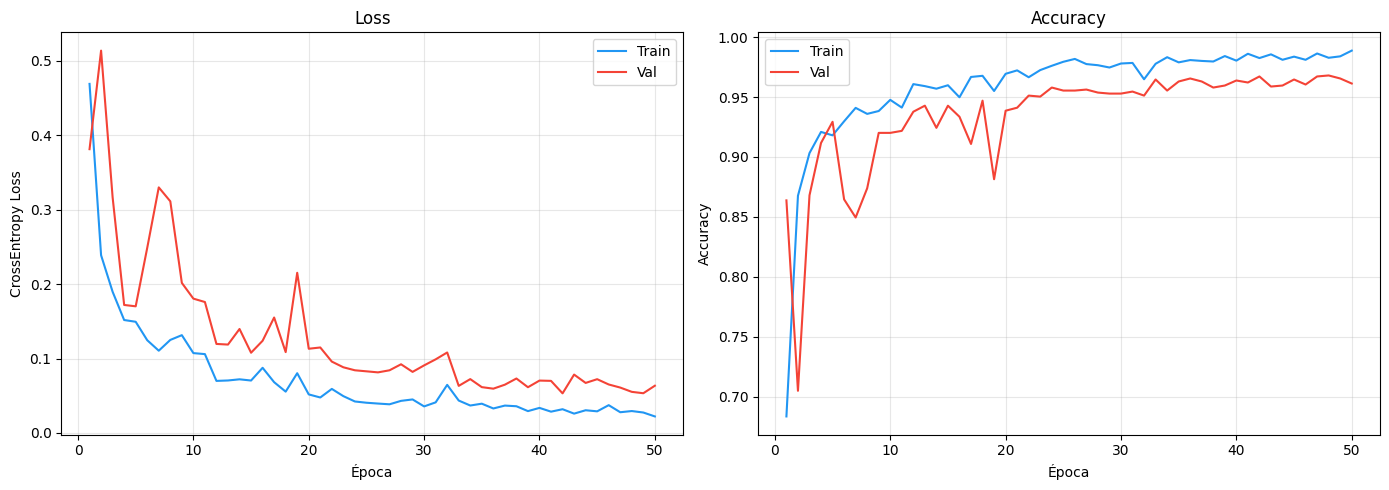

In [346]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, actual_epochs + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train", color="#2196F3")
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   color="#F44336")
axes[0].set_title("Loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train", color="#2196F3")
axes[1].plot(epochs_range, history["val_acc"],   label="Val",   color="#F44336")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluación en test set

Classification Report:
                precision    recall  f1-score   support

   Normal (-1)       1.00      0.96      0.98       468
     Caída (0)       0.93      0.95      0.94       236
Post-caída (1)       0.83      1.00      0.91        64

      accuracy                           0.96       768
     macro avg       0.92      0.97      0.94       768
  weighted avg       0.96      0.96      0.96       768



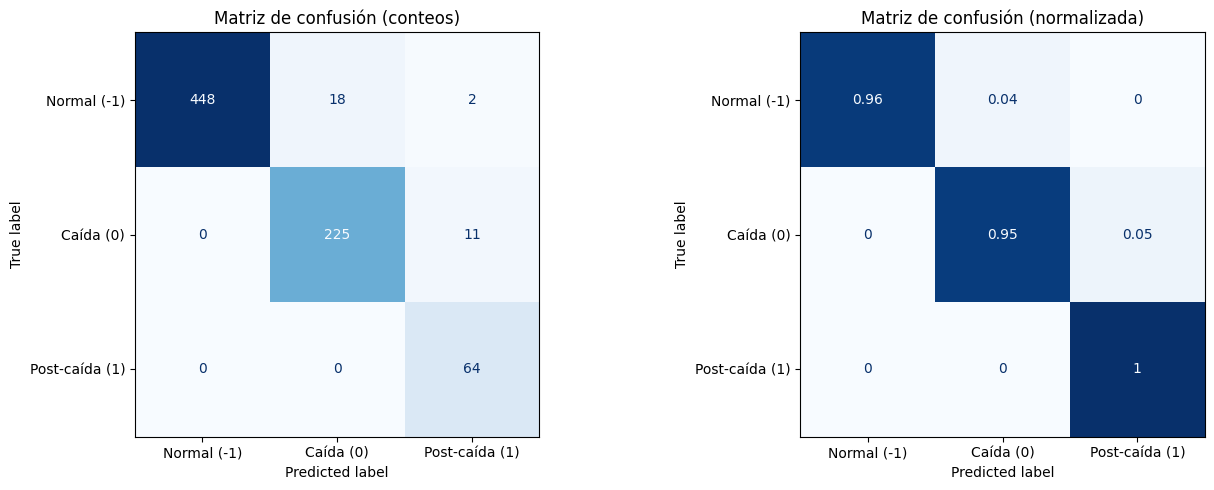

In [347]:
# Cargar el mejor modelo
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteos absolutos
disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de confusión (conteos)")

# Normalizada
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=LABEL_NAMES)
disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Matriz de confusión (normalizada)")

plt.tight_layout()
plt.show()

         Clase  Precision  Recall    F1  Support
   Normal (-1)      1.000   0.957 0.978      468
     Caída (0)      0.926   0.953 0.939      236
Post-caída (1)      0.831   1.000 0.908       64


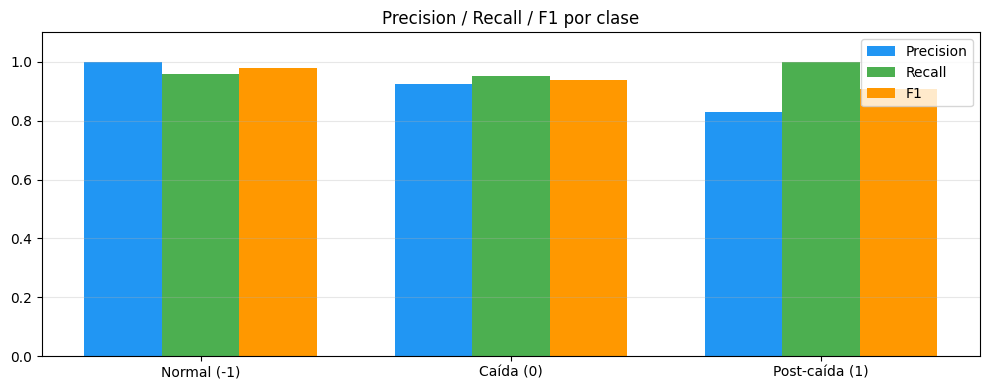

In [348]:
# Métricas por clase
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None
)

metrics_df = pd.DataFrame({
    "Clase": LABEL_NAMES,
    "Precision": precision.round(3),
    "Recall":    recall.round(3),
    "F1":        f1.round(3),
    "Support":   support,
})
print(metrics_df.to_string(index=False))

# Gráfico de métricas por clase
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(N_CLASSES)
width = 0.25
ax.bar(x - width, precision, width, label="Precision", color="#2196F3")
ax.bar(x,         recall,    width, label="Recall",    color="#4CAF50")
ax.bar(x + width, f1,        width, label="F1",        color="#FF9800")
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES)
ax.set_ylim(0, 1.1)
ax.set_title("Precision / Recall / F1 por clase")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Guardar modelo final

In [350]:
# Guardar con metadatos del modelo
checkpoint = {
    "model_state_dict": model.state_dict(),
    "hyperparams": {
        "input_size":  N_FEATURES,
        "hidden_size": HIDDEN_SIZE,
        "num_layers":  NUM_LAYERS,
        "num_classes": N_CLASSES,
        "dropout":     DROPOUT,
        "window":      WINDOW,
    },
    "label_map":   LABEL_MAP,
    "label_names": LABEL_NAMES,
}
save_path = DATA_DIR / "fall_lstm_final.pt"
torch.save(checkpoint, save_path)
print(f"Modelo guardado en: {save_path}")

Modelo guardado en: lstm_data\fall_lstm_final.pt
